In [5]:
# I want to make a plot of clustering length of quasars as a function of redshift that I have 
# collected from the literature. Each research paper will have measurement of clustering length
# at a particular redshift. We begin with collecting the data from the literature.

import numpy as np
import matplotlib.pyplot as plt
import re

# Define the data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots2.0/"

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')
# plt.grid(visible=False)

# Read the Clustering_Literature.csv file form the data directory
data = np.genfromtxt(DATA_DIRECTORY + 'Clustering_Literature.csv', delimiter=',', skip_header=1, dtype=None, encoding=None)

paper_name = data[:,0]
red_range = data[:,5]
clust_length = data[:,7]
clust_slope = data[:,8]

# Put an '\' before the '&' character in the paper_name
paper_name = [paper_name[i].replace('&', '\&') for i in range(len(paper_name))]

# convert the red_range which is in the form z_min - z_max to an array of z_min and z_max
red_range = np.array([red_range[i].split('-') for i in range(len(red_range))], dtype=float)

# convert clust_range which is in the form of r + delr_u/ -delr_d.
clust_length = [re.split("\+|/", clust_length[i]) for i in range(len(clust_length))]

# convert clust_slope which is in the form of game + delgam_u/ -delgam_d.
clust_slope = [re.split("\+|/", clust_slope[i]) for i in range(len(clust_slope))]

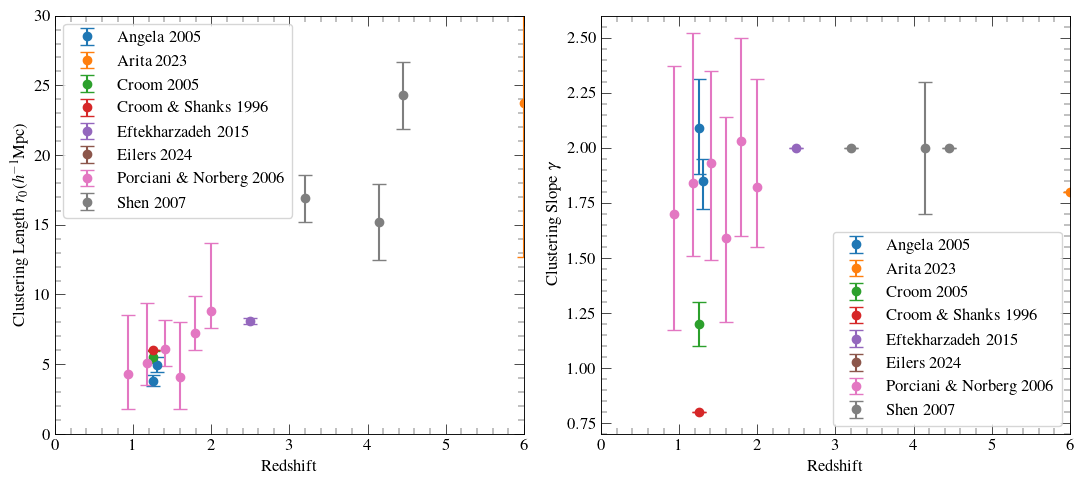

In [2]:
# Group the data points by the paper name
paper_name_unique = np.unique(paper_name)
paper_name_grouped = [np.where(np.array(paper_name) == paper_name_unique[i]) for i in range(len(paper_name_unique))]
clust_length_grouped = [np.array([clust_length[paper_name_grouped[i][0][j]] for j in range(len(paper_name_grouped[i][0]))], dtype=float) for i in range(len(paper_name_unique))]
clust_slope_grouped = [np.array([clust_slope[paper_name_grouped[i][0][j]] for j in range(len(paper_name_grouped[i][0]))], dtype=float) for i in range(len(paper_name_unique))]
red_range_grouped = [np.array([red_range[paper_name_grouped[i][0][j]] for j in range(len(paper_name_grouped[i][0]))], dtype=float) for i in range(len(paper_name_unique))]

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for i in range(len(paper_name_unique)):
    ax[0].errorbar((red_range_grouped[i][:,0] + red_range_grouped[i][:,1])/2, clust_length_grouped[i][:,0], yerr=[clust_length_grouped[i][:,1], np.absolute(clust_length_grouped[i][:,2])], fmt='o', capsize=5, label=paper_name_unique[i])
    ax[1].errorbar((red_range_grouped[i][:,0] + red_range_grouped[i][:,1])/2, clust_slope_grouped[i][:,0], yerr=[clust_slope_grouped[i][:,1], np.absolute(clust_slope_grouped[i][:,2])], fmt='o', capsize=5, label=paper_name_unique[i])

ax[0].set_xlabel('Redshift')
ax[0].set_ylabel(r'Clustering Length $r_0$($h^{-1}$Mpc)')
ax[0].legend()
ax[0].set_xlim(0, 6)
ax[0].set_ylim(0, 30)
ax[0].grid(visible=False)

ax[1].set_xlabel('Redshift')
ax[1].set_ylabel(r'Clustering Slope $\gamma$')
ax[1].legend()
ax[1].set_xlim(0, 6)
ax[1].set_ylim(0.7, 2.6)
ax[1].grid(visible=False)

# save the plot as a pdf file
plt.tight_layout()
plt.savefig(PLOT_DIRECTORY + 'ClusteringLiterature.pdf')

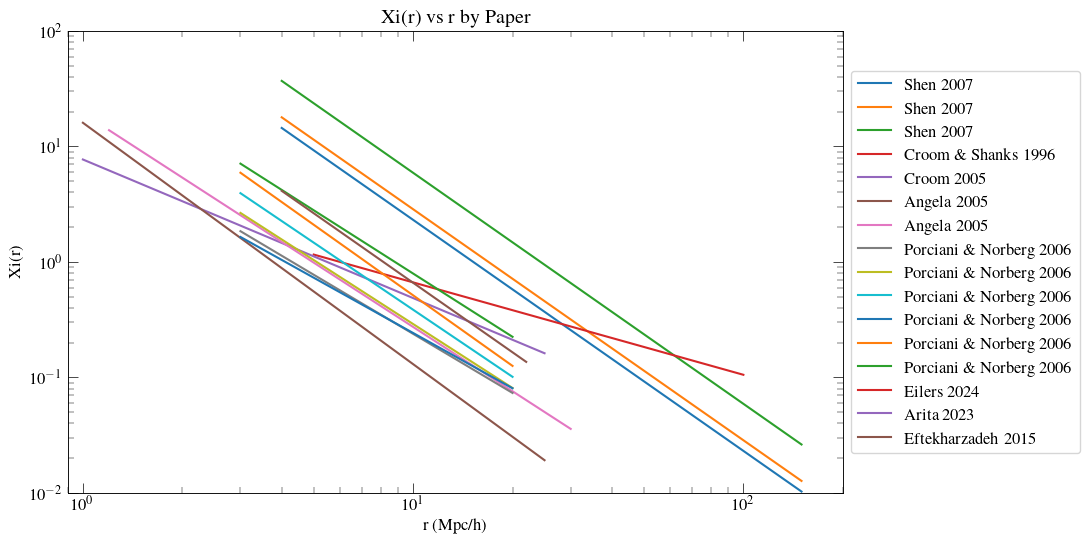

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to extract numerical values from a column with uncertainty
def extract_value_with_uncertainty(column):
    return column.str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Escape special characters for LaTeX compatibility
def escape_latex_characters(text):
    return text.replace('&', r'\&').replace('%', r'\%').replace('$', r'\$').replace('#', r'\#')

# Load the data from the CSV file
file_path = DATA_DIRECTORY + 'Clustering_Literature.csv'
data = pd.read_csv(file_path)

# Extract clustering length (r0) and correlation slope (gamma)
data['clustering length'] = extract_value_with_uncertainty(data['clustering length'])
data['correlation slope'] = extract_value_with_uncertainty(data['correlation slope'])

# Extract clustering range (r_min and r_max) correctly
clustering_range = data['clustering range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
clustering_range.columns = ['r_min', 'r_max']
clustering_range['r_min'] = clustering_range['r_min'].astype(float)
clustering_range['r_max'] = clustering_range['r_max'].astype(float)

# Add the extracted clustering range to the data
data = pd.concat([data, clustering_range], axis=1)

# Escape LaTeX characters in the Paper column
data['Paper'] = data['Paper'].apply(escape_latex_characters)

# Generate the plot
plt.figure(figsize=(10, 6))

# Loop through each paper and plot its Xi(r) line over the range r_min to r_max
unique_papers = data['Paper'].unique()

for paper in unique_papers:
    paper_data = data[data['Paper'] == paper]
    
    for _, row in paper_data.iterrows():
        # Generate r values from r_min to r_max
        r_values = np.linspace(row['r_min'], row['r_max'], 100)
        
        # Calculate Xi(r) = (r / r_0) ^ (-gamma)
        Xi_r = (r_values / row['clustering length']) ** (-row['correlation slope'])
        
        # Plot the line for this paper
        plt.plot(r_values, Xi_r, label=f"{paper}")

plt.xlabel('r (Mpc/h)')
plt.ylabel('Xi(r)')
plt.title('Xi(r) vs r by Paper')
plt.xscale('log')
plt.yscale('log')
plt.grid(False)

# Put the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Increase the range of x such that all the data points are visible
plt.xlim(0.9, 200)
plt.ylim(0.01, 100)

# Show the plot
plt.show()


/tmp/ipykernel_5013/1840997752.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab10')  # You can change this to any colormap


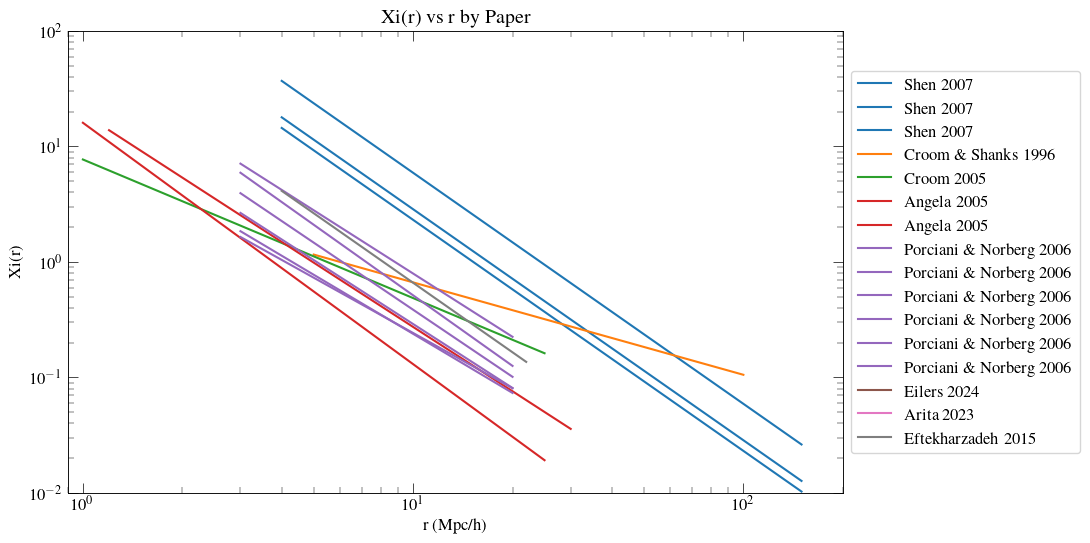

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Function to extract numerical values from a column with uncertainty
def extract_value_with_uncertainty(column):
    return column.str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Escape special characters for LaTeX compatibility
def escape_latex_characters(text):
    return text.replace('&', r'\&').replace('%', r'\%').replace('$', r'\$').replace('#', r'\#')

# Load the data from the CSV file
file_path = DATA_DIRECTORY + 'Clustering_Literature.csv'  # Update the path to your CSV
data = pd.read_csv(file_path)

# Extract clustering length (r0) and correlation slope (gamma)
data['clustering length'] = extract_value_with_uncertainty(data['clustering length'])
data['correlation slope'] = extract_value_with_uncertainty(data['correlation slope'])

# Extract clustering range (r_min and r_max) correctly
clustering_range = data['clustering range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
clustering_range.columns = ['r_min', 'r_max']
clustering_range['r_min'] = clustering_range['r_min'].astype(float)
clustering_range['r_max'] = clustering_range['r_max'].astype(float)

# Add the extracted clustering range to the data
data = pd.concat([data, clustering_range], axis=1)

# Escape LaTeX characters in the Paper column
data['Paper'] = data['Paper'].apply(escape_latex_characters)

# Define a colormap and assign a color to each paper
unique_papers = data['Paper'].unique()
cmap = get_cmap('tab10')  # You can change this to any colormap
paper_colors = {paper: cmap(i) for i, paper in enumerate(unique_papers)}

# Generate the plot
plt.figure(figsize=(10, 6))

# Loop through each paper and plot its Xi(r) line over the range r_min to r_max
for paper in unique_papers:
    paper_data = data[data['Paper'] == paper]
    
    for _, row in paper_data.iterrows():
        # Generate r values from r_min to r_max
        r_values = np.linspace(row['r_min'], row['r_max'], 100)
        
        # Calculate Xi(r) = (r / r_0) ^ (-gamma)
        Xi_r = (r_values / row['clustering length']) ** (-row['correlation slope'])
        
        # Plot the line for this paper with the same color
        plt.plot(r_values, Xi_r, label=f"{paper}", color=paper_colors[paper])

plt.xlabel('r (Mpc/h)')
plt.ylabel('Xi(r)')
plt.title('Xi(r) vs r by Paper')
plt.xscale('log')
plt.yscale('log')
plt.grid(False)

# Put the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Increase the range of x and y axes such that all the data points are visible
plt.xlim(0.9, 200)
plt.ylim(0.01, 100)

# Show the plot
plt.show()


/tmp/ipykernel_5013/3281049598.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab10')  # You can change this to any colormap


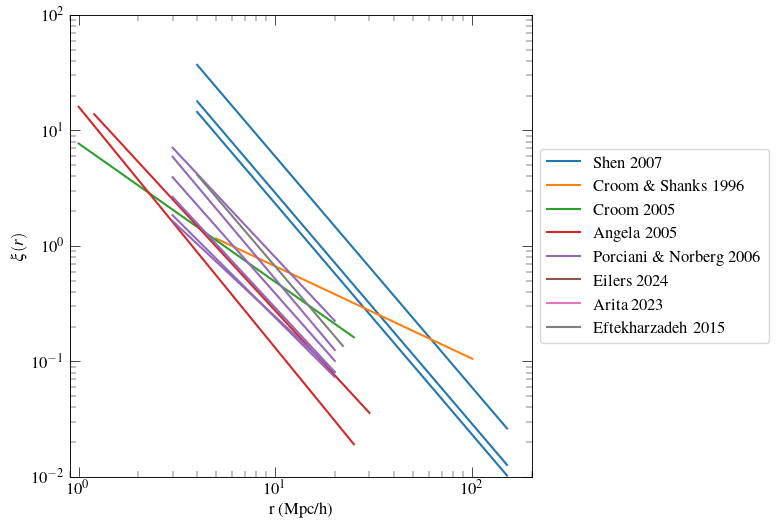

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Function to extract numerical values from a column with uncertainty
def extract_value_with_uncertainty(column):
    return column.str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Escape special characters for LaTeX compatibility
def escape_latex_characters(text):
    return text.replace('&', r'\&').replace('%', r'\%').replace('$', r'\$').replace('#', r'\#')

# Load the data from the CSV file
file_path = DATA_DIRECTORY + 'Clustering_Literature.csv'  # Update the path to your CSV
data = pd.read_csv(file_path)

# Extract clustering length (r0) and correlation slope (gamma)
data['clustering length'] = extract_value_with_uncertainty(data['clustering length'])
data['correlation slope'] = extract_value_with_uncertainty(data['correlation slope'])

# Extract clustering range (r_min and r_max) correctly
clustering_range = data['clustering range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
clustering_range.columns = ['r_min', 'r_max']
clustering_range['r_min'] = clustering_range['r_min'].astype(float)
clustering_range['r_max'] = clustering_range['r_max'].astype(float)

# Add the extracted clustering range to the data
data = pd.concat([data, clustering_range], axis=1)

# Extract the redshift range (z_min and z_max) correctly
redshift_range = data['redshift range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
redshift_range.columns = ['z_min', 'z_max']
redshift_range['z_min'] = redshift_range['z_min'].astype(float)
redshift_range['z_max'] = redshift_range['z_max'].astype(float)

# Escape LaTeX characters in the Paper column
data['Paper'] = data['Paper'].apply(escape_latex_characters)

# Define a colormap and assign a color to each paper
unique_papers = data['Paper'].unique()
cmap = get_cmap('tab10')  # You can change this to any colormap
paper_colors = {paper: cmap(i) for i, paper in enumerate(unique_papers)}

# Generate the plot
plt.figure(figsize=(10, 6))

# Loop through each paper and plot its Xi(r) line over the range r_min to r_max
for paper in unique_papers:
    paper_data = data[data['Paper'] == paper]
    plotted = False  # To track if we've added the paper to the legend
    
    for _, row in paper_data.iterrows():
        # Generate r values from r_min to r_max
        r_values = np.linspace(row['r_min'], row['r_max'], 100)
        
        # Calculate Xi(r) = (r / r_0) ^ (-gamma)
        Xi_r = (r_values / row['clustering length']) ** (-row['correlation slope'])
        
        # Plot the line for this paper with the same color and add label only once
        if not plotted:
            plt.plot(r_values, Xi_r, label=f"{paper}", color=paper_colors[paper])
            plotted = True  # Ensure the label is added only once
        else:
            plt.plot(r_values, Xi_r, color=paper_colors[paper])  # No label after the first plot

plt.xlabel('r (Mpc/h)')
plt.ylabel(r'$\xi(r)$')
# plt.title('Xi(r) vs r by Paper')
plt.xscale('log')
plt.yscale('log')
plt.grid(False)
plt.gca().set_box_aspect(1)

# Put the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Increase the range of x and y axes such that all the data points are visible
plt.xlim(0.9, 200)
plt.ylim(0.01, 100)

# Show the plot
plt.show()


/tmp/ipykernel_8656/1447572585.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cmap = get_cmap('viridis')  # You can change this to 'Set1', 'Dark2', 'Accent', etc., for other qualitative palettes


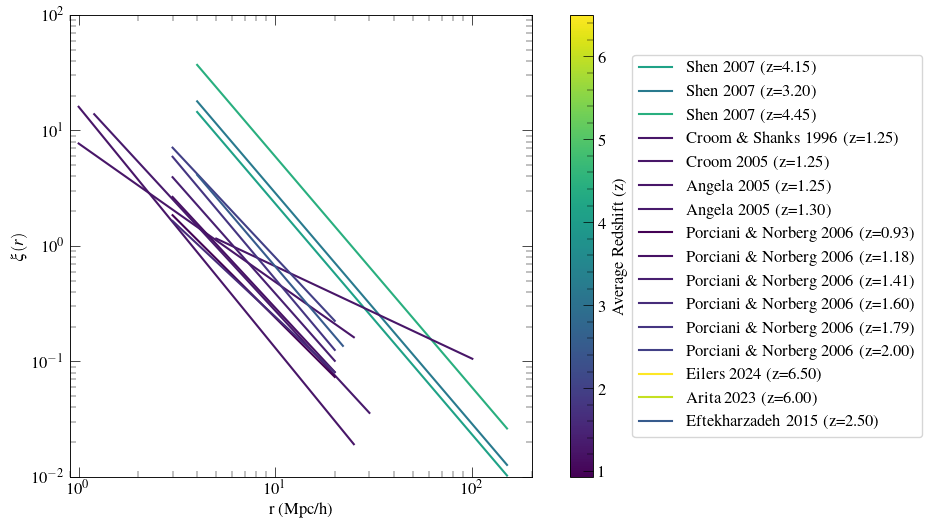

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.colors import Normalize

# Function to extract numerical values from a column with uncertainty
def extract_value_with_uncertainty(column):
    return column.str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Escape special characters for LaTeX compatibility
def escape_latex_characters(text):
    return text.replace('&', r'\&').replace('%', r'\%').replace('$', r'\$').replace('#', r'\#')

# Load the data from the CSV file
file_path = DATA_DIRECTORY + 'Clustering_Literature.csv'  # Update the path to your CSV
data = pd.read_csv(file_path)

# Extract clustering length (r0) and correlation slope (gamma)
data['clustering length'] = extract_value_with_uncertainty(data['clustering length'])
data['correlation slope'] = extract_value_with_uncertainty(data['correlation slope'])

# Extract clustering range (r_min and r_max) correctly
clustering_range = data['clustering range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
clustering_range.columns = ['r_min', 'r_max']
clustering_range['r_min'] = clustering_range['r_min'].astype(float)
clustering_range['r_max'] = clustering_range['r_max'].astype(float)

# Add the extracted clustering range to the data
data = pd.concat([data, clustering_range], axis=1)

# Extract the redshift range (z_min and z_max) correctly
redshift_range = data['redshift range'].str.extract(r'(\d+\.?\d*) - (\d+\.?\d*)')
redshift_range.columns = ['z_min', 'z_max']
redshift_range['z_min'] = redshift_range['z_min'].astype(float)
redshift_range['z_max'] = redshift_range['z_max'].astype(float)

# Add the extracted redshift range to the data
data = pd.concat([data, redshift_range], axis=1)

# Calculate the average redshift for each row
data['average_redshift'] = data[['z_min', 'z_max']].mean(axis=1)

# Escape LaTeX characters in the Paper column
data['Paper'] = data['Paper'].apply(escape_latex_characters)

# Define a qualitative colormap (e.g., tab20) based on redshift
cmap = cmap = get_cmap('viridis')  # You can change this to 'Set1', 'Dark2', 'Accent', etc., for other qualitative palettes
norm = Normalize(vmin=data['average_redshift'].min(), vmax=data['average_redshift'].max())

# Generate the plot
plt.figure(figsize=(10, 6))

# Loop through each paper and plot its Xi(r) line over the range r_min to r_max
for _, row in data.iterrows():
    # Generate r values from r_min to r_max
    r_values = np.linspace(row['r_min'], row['r_max'], 100)
    
    # Calculate Xi(r) = (r / r_0) ^ (-gamma)
    Xi_r = (r_values / row['clustering length']) ** (-row['correlation slope'])
    
    # Determine the color based on the average redshift
    color = cmap(norm(row['average_redshift']))
    
    # Plot the line with the color and add the label with the paper name only for the first occurrence
    plt.plot(r_values, Xi_r, label=f"{row['Paper']} (z={row['average_redshift']:.2f})", color=color)

plt.xlabel('r (Mpc/h)')
plt.ylabel(r'$\xi(r)$')
# plt.title('Xi(r) vs r by Paper')
plt.xscale('log')
plt.yscale('log')
plt.grid(False)
plt.gca().set_box_aspect(1)

# Add a colorbar to indicate the redshift scale
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Average Redshift (z)')

# Put the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5))

# Increase the range of x and y axes such that all the data points are visible
plt.xlim(0.9, 200)
plt.ylim(0.01, 100)

# Save the plot as a PDF file
plt.savefig(PLOT_DIRECTORY + 'Xi_r_by_Paper_with_Redshift.pdf')

# Show the plot
plt.show()
